# Estudio comparativo de algoritmos en un problema de k-armed bandit: algoritmos UCB-1 y UCB-2.

*Description:* El experimento compara el rendimiento de algoritmos epsilon-greedy en un problema de k-armed bandit.
Se generan gráficas de recompensas promedio para cada algoritmo.




## Preparación del entorno


In [ ]:
#@title Copiar el repositorio.

!git clone https://github.com/JoseHernandez11/k_brazos_JMHJDRJG.git
%cd k_brazos_JMHJDRJG

!pip install -r requirements.txt


Cloning into 'eml_k_bandit'...
remote: Enumerating objects: 66, done.
remote: Counting objects: 100% (66/66), done.
remote: Compressing objects: 100% (47/47), done.
remote: Total 66 (delta 28), reused 42 (delta 14), pack-reused 0 (from 0)
Receiving objects: 100% (66/66), 318.16 KiB | 6.77 MiB/s, done.
Resolving deltas: 100% (28/28), done.


In [1]:
#@title Importamos todas las clases y funciones

import sys

# Añadir los directorio fuentes al path de Python
sys.path.append('/content/k_brazos_JMHJDRJG')


# Verificar que se han añadido correctamente
print(sys.path)

import numpy as np
from typing import List

from algorithms import Algorithm,  UCB1, UCB2
from arms import ArmNormal, ArmBinomial, ArmBernoulli,  Bandit
from plotting import plot_average_rewards, plot_optimal_selections, plot_arm_statistics, plot_regret

# Fijar la semilla para reproducibilidad

seed = 42
np.random.seed(seed)  


['c:\\Users\\josem\\anaconda3\\envs\\EML_P1E1\\python310.zip', 'c:\\Users\\josem\\anaconda3\\envs\\EML_P1E1\\DLLs', 'c:\\Users\\josem\\anaconda3\\envs\\EML_P1E1\\lib', 'c:\\Users\\josem\\anaconda3\\envs\\EML_P1E1', '', 'c:\\Users\\josem\\anaconda3\\envs\\EML_P1E1\\lib\\site-packages', 'c:\\Users\\josem\\anaconda3\\envs\\EML_P1E1\\lib\\site-packages\\win32', 'c:\\Users\\josem\\anaconda3\\envs\\EML_P1E1\\lib\\site-packages\\win32\\lib', 'c:\\Users\\josem\\anaconda3\\envs\\EML_P1E1\\lib\\site-packages\\Pythonwin', '/content/k_brazos_JMHJDRJG']


### Definición del ejecutador de experimentos.

Cada algoritmo de los que se van a comparar se ejecuta en un problema de k-armed bandit durante un número de pasos de tiempo y ejecuciones determinado.
La función base *run_experiment* ha sido modificada respecto a la proporcionada como base, haciendo que devuelva información extra que nos permitirá crear todas las gráficas pedidas en el enunciado de la práctica. De esta forma, podremos comparar:

* Evolución de la recompensa promedia respecto al número de iteraciones entre los diferentes algoritmos y configuraciones.
* Evolución del porcentaje de selecciones óptimas respecto al número de iteraciones entre los diferentes algoritmos y configuraciones.
* Estadísticas de los brazos (veces seleccionado, recompensa del brazo, cúal es el óptimo) por cada algoritmo y configuración.
* Evolución del regret acumulado promedio respecto al número de iteraciones entre los diferentes algoritmos y configuraciones


Para UCB-1 se fijará $c=1$, como en la formulación original. Para UCB-2, elegimos tres valores de $\alpha = [0.01,0.1, 0.9] $, aunque ya hemos comentado en la parte documental que valores pequeños suelen obtener resultados satisfactorios.

In [2]:
def run_experiment(bandit: Bandit, algorithms: List[Algorithm], steps: int, runs: int):

    optimal_arm = bandit.optimal_arm  # Necesario para calcular el porcentaje de selecciones óptimas.

    rewards = np.zeros((len(algorithms), steps)) # Matriz para almacenar las recompensas promedio.

    optimal_selections = np.zeros((len(algorithms), steps))  # Matriz para almacenar el porcentaje de selecciones óptimas.
    
    regret_accumulated = np.zeros((len(algorithms), steps))  # Matriz para almacenar el rechazo promedio.

    arm_stats = np.zeros((len(algorithms), bandit.k, steps))  # Matriz para almacenar las estadísticas de los brazos.

    selected_arms = np.zeros ((len(algorithms), bandit.k)) # Matriz para almacenar los brazos seleccionados.

    np.random.seed(seed)  # Asegurar reproducibilidad de resultados.

    for run in range(runs):
        current_bandit = Bandit(arms=bandit.arms)

        for algo in algorithms:
            algo.reset() # Reiniciar los valores de los algoritmos.

        total_rewards_per_algo = np.zeros(len(algorithms)) # Acumulador de recompensas por algoritmo. Necesario para calcular el promedio.

        for step in range(steps):
            for idx, algo in enumerate(algorithms):
                chosen_arm = algo.select_arm() # Seleccionar un brazo según la política del algoritmo.
                reward = current_bandit.pull_arm(chosen_arm) # Obtener la recompensa del brazo seleccionado.
                regret_accumulated[idx, step] = regret_accumulated[idx, step - 1] + (current_bandit.pull_arm(optimal_arm) - reward) if step > 0 else (current_bandit.pull_arm(optimal_arm) - reward)

                algo.update(chosen_arm, reward) # Actualizar el valor estimado del brazo seleccionado.

                rewards[idx, step] += reward # Acumular la recompensa obtenida en la matriz rewards para el algoritmo idx en el paso step.
                total_rewards_per_algo[idx] += reward # Acumular la recompensa obtenida en total_rewards_per_algo para el algoritmo idx.

                if chosen_arm == optimal_arm:
                    optimal_selections[idx, step] += 1

                for arm in range(bandit.k):
                    arm_stats[idx, arm, step] = current_bandit.pull_arm(arm)
                    if arm == chosen_arm:
                        selected_arms[idx, arm] += 1

    rewards /= runs
    optimal_selections /= runs
    regret_accumulated /= runs
    
    arm_stats_mean = arm_stats.mean(axis=2)
    arm_stats_lists = []  # Lista de diccionarios para almacenar las estadísticas de los brazos.

    for algo in range(len(algorithms)):
        arm_stats_dict = {}
        for arm in range(bandit.k):
            arm_stats_dict[arm+1] = {  # Diccionario para almacenar las estadísticas de cada uno de los brazos.
                "avg_reward": arm_stats_mean[algo, arm],
                "times_selected": round(selected_arms[algo, arm] / runs),
                "optimal_arm": 1 if arm == optimal_arm else 0
            }
        arm_stats_lists.append(arm_stats_dict)

        
    return rewards, optimal_selections, arm_stats_lists, regret_accumulated

## Ejecución del experimento para distribución normal



In [3]:

# Parámetros del experimento

k = 10  # Número de brazos
steps = 1000  # Número de pasos que se ejecutarán cada algoritmo
runs = 500  # Número de ejecuciones

# Creación del bandit
bandit = Bandit(arms=ArmNormal.generate_arms(k)) # Generar un bandido con k brazos de distribución normal

optimal_arm = bandit.optimal_arm
print(f"Optimal arm: {optimal_arm + 1} with expected reward={bandit.get_expected_value(optimal_arm)}")

# Definir los algoritmos a comparar. En este caso son 3 algoritmos epsilon-greedy con diferentes valores de epsilon.
algorithms = [UCB1(k), UCB2(k, alpha=0.01), UCB2(k, alpha=0.1), UCB2(k, alpha=0.9)]  # Lista de algoritmos a comparar

# Ejecutar el experimento y obtener las recompensas promedio y promedio de las selecciones óptimas
rewards, optimal_selections, arm_stats_list, regret_accumulated = run_experiment(bandit, algorithms, steps, runs)


Optimal arm: 8 with expected reward=9.56


### Visualización de los resultados

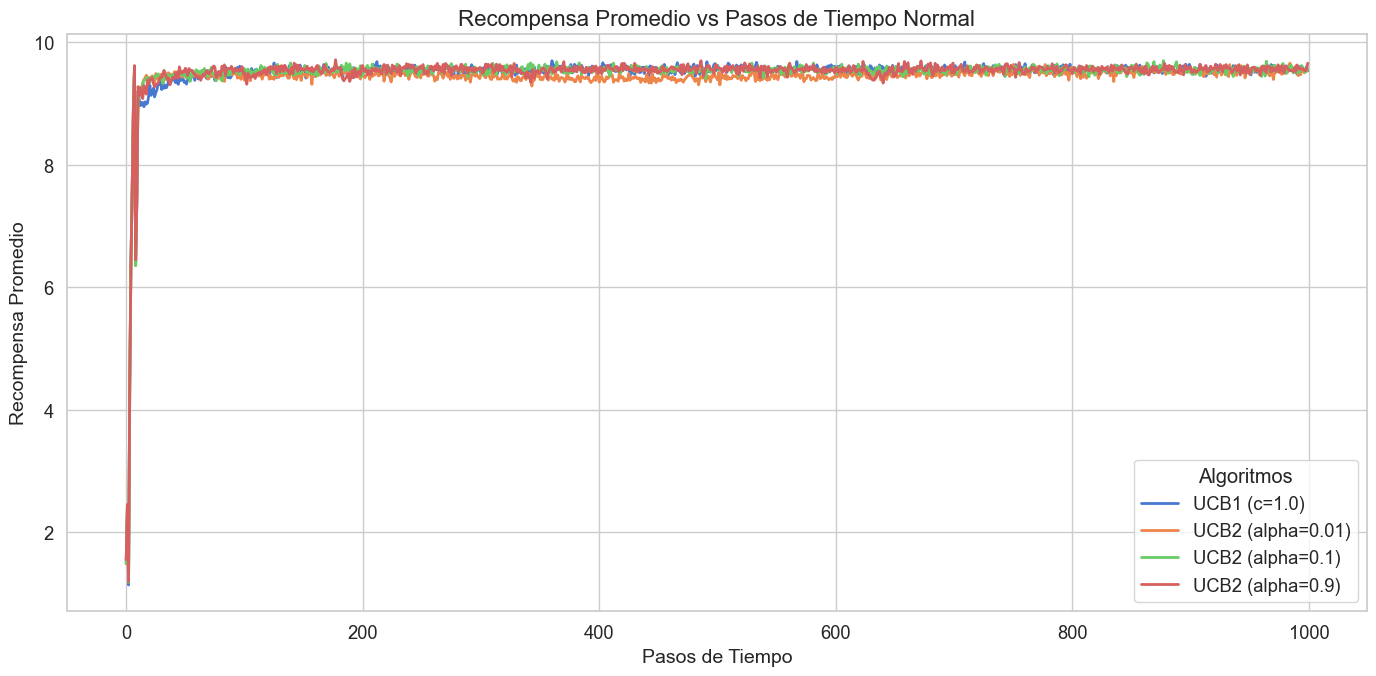

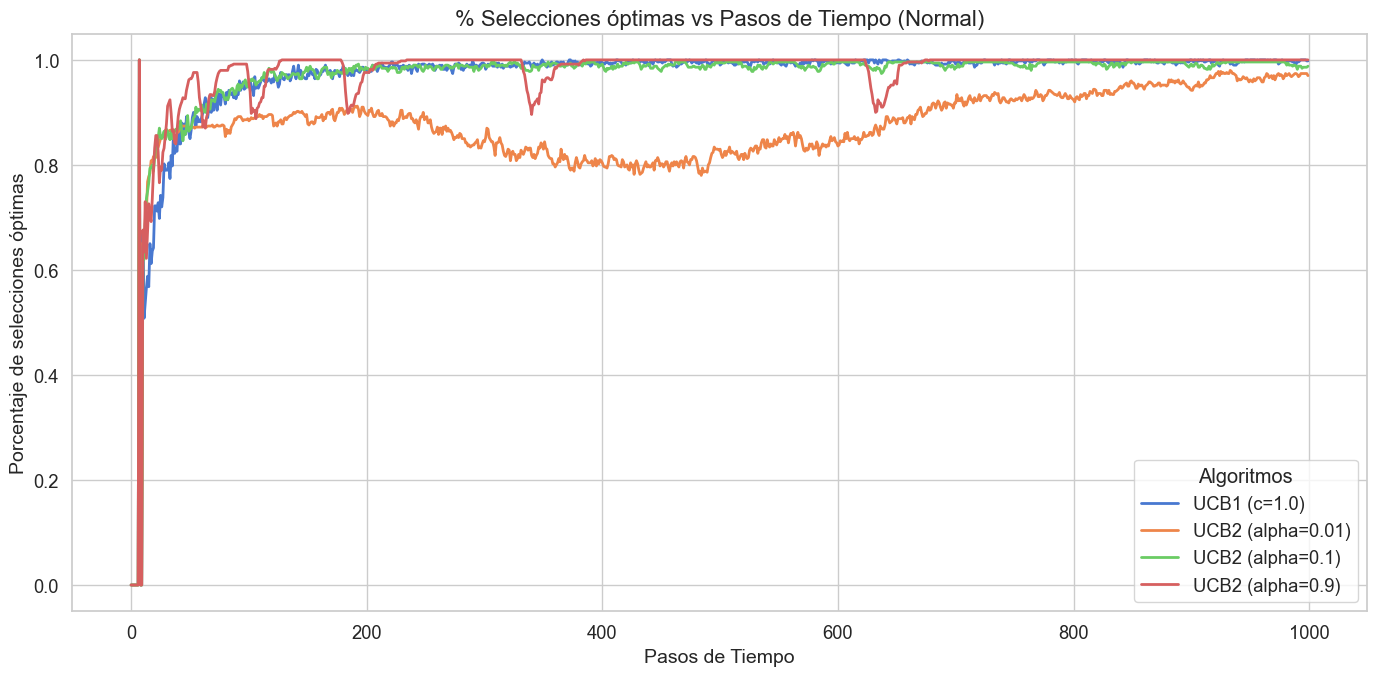

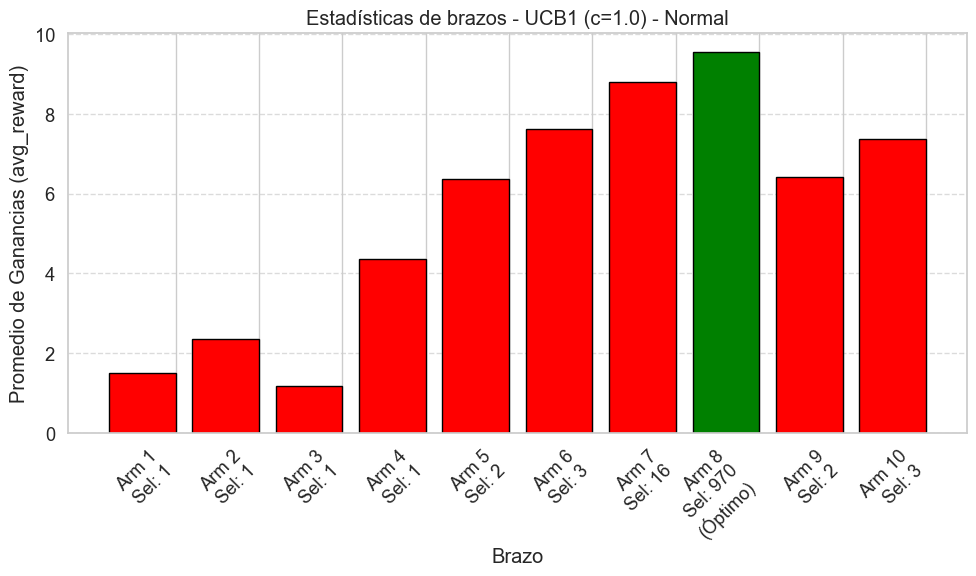

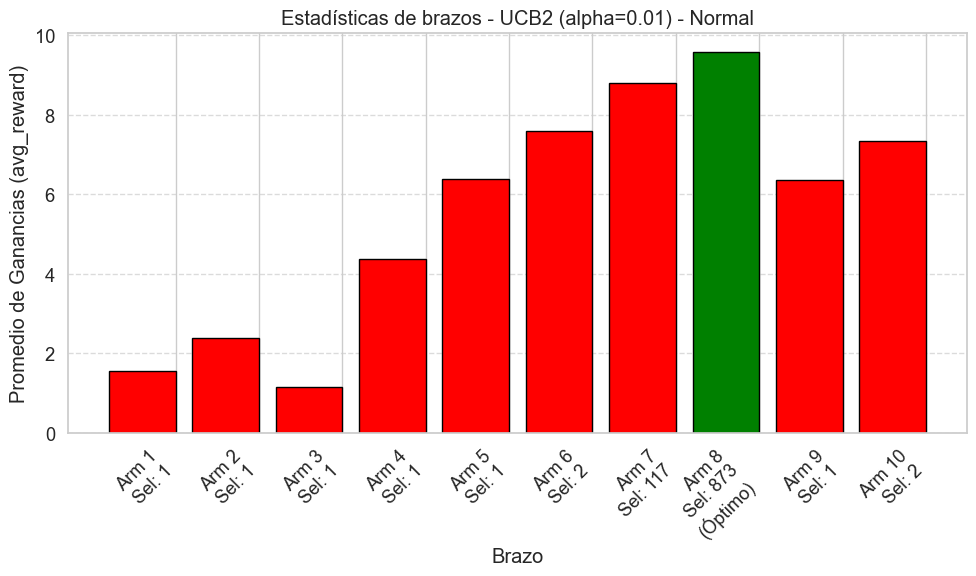

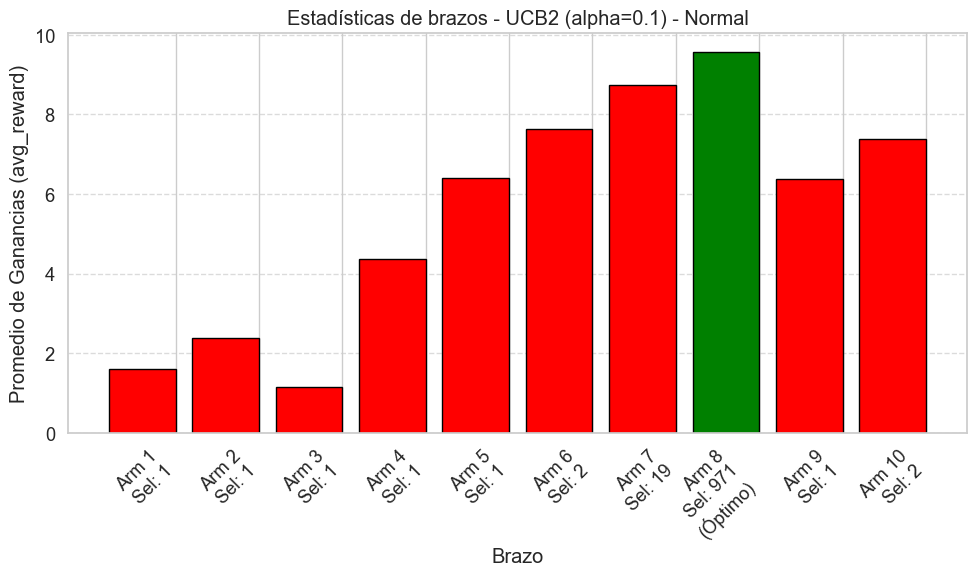

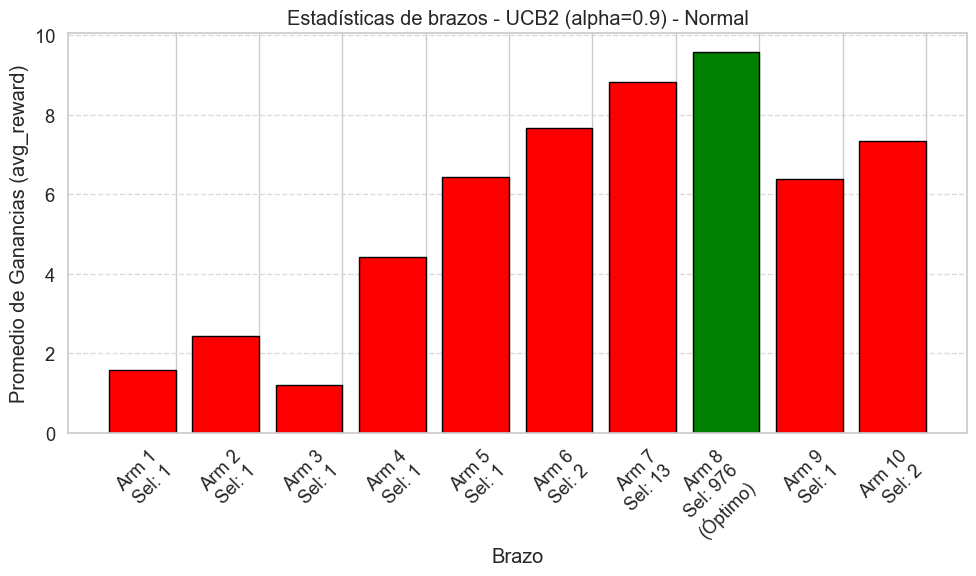

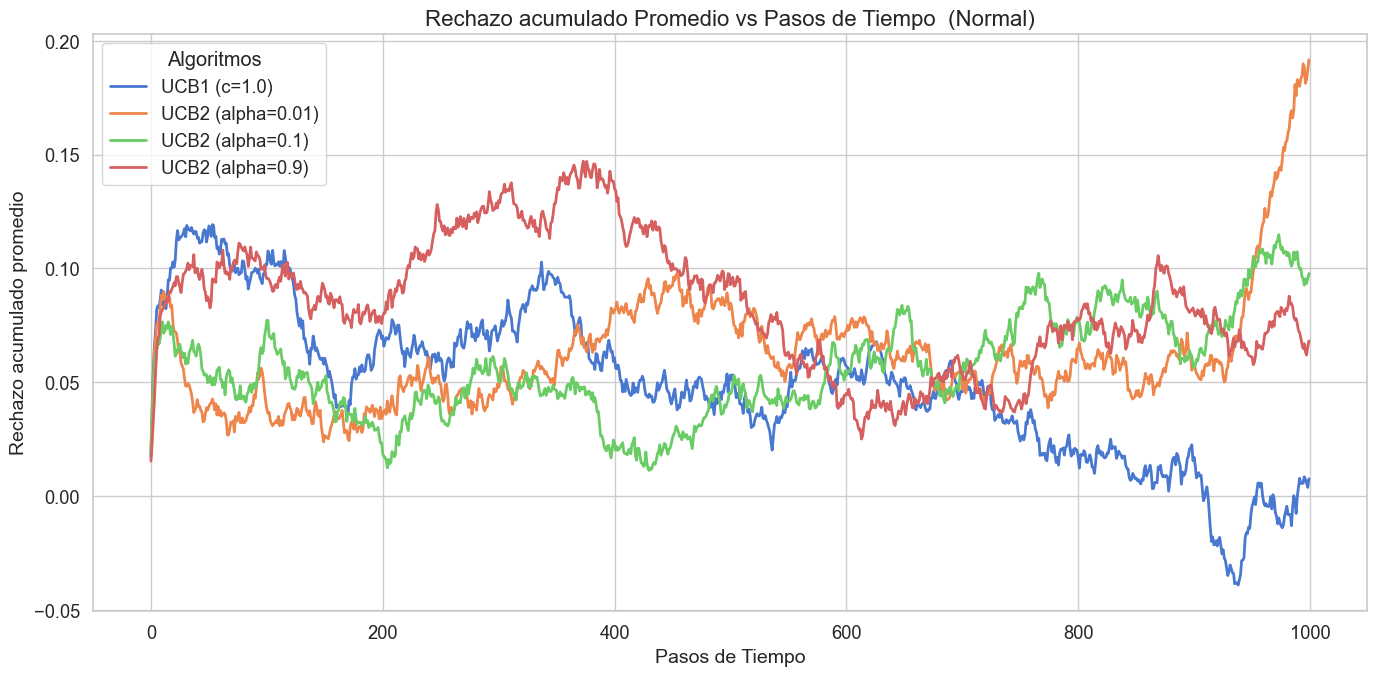

In [4]:

# Graficar los resultados
plot_average_rewards(steps, rewards, algorithms)
plot_optimal_selections(steps, optimal_selections, algorithms)
plot_arm_statistics(arm_stats_list, algorithms)
plot_regret(steps, regret_accumulated, algorithms)


### Análisis de los resultados

En las gráficas podemos apreciar distintas representaciones de los resultados obtenidos. En la gráfica de evolución de recompensa acumulada, podemos apreciar como todas las configuraciones de UCB consiguen una convergencia rápida hacia la recompensa máxima. En la gráfica del porcentaje de selecciones óptimas apreciamos que las mejores configuraciones son UCB-1 y UCB-2 con $\alpha=0.1$, lo que podemos confirmar también en la gráfica del rechazo acumulado. También cabe comentar las oscilaciones que vemos  en todos los métodos UCB al principio de la gráfica de evolución de la recompensa acumulada respecto a las iteraciones. Si miramos las ecuaciones 3 y 4 (parte documental), podemos averiguar que estas oscilaciones se corresponden con la primera iteración en la que se explora el brazo óptimo, el valor de las funciones UCB aumenta mucho y se explota durante unas cuantas épocas hasta que el térmite exploratorio aumenta, al aumentar $t$. Más adelante, cuando todos los brazos han sido explorados todos los brazos, vuelve a converger ya de forma estable.

## Experimento para bandido distribución Bernoulli

In [5]:
# Parámetros del experimento


k = 10  # Número de brazos
steps = 1000  # Número de pasos que se ejecutarán cada algoritmo
runs = 500  # Número de ejecuciones

# Creación del bandit
bandit = Bandit(arms=ArmBernoulli.generate_arms(k)) # Generar un bandido con k brazos de distribución normal

optimal_arm = bandit.optimal_arm
print(f"Optimal arm: {optimal_arm + 1} with expected reward={bandit.get_expected_value(optimal_arm)}")

# Definir los algoritmos a comparar. En este caso son 3 algoritmos epsilon-greedy con diferentes valores de epsilon.
algorithms = [UCB1(k), UCB2(k, alpha=0.01), UCB2(k, alpha=0.1), UCB2(k, alpha=0.9)]  # Lista de algoritmos a comparar

# Ejecutar el experimento y obtener las recompensas promedio y promedio de las selecciones óptimas
rewards, optimal_selections, arm_stats_list, regret_accumulated = run_experiment(bandit, algorithms, steps, runs)


Optimal arm: 5 with expected reward=0.77


### Visualización de los resultados

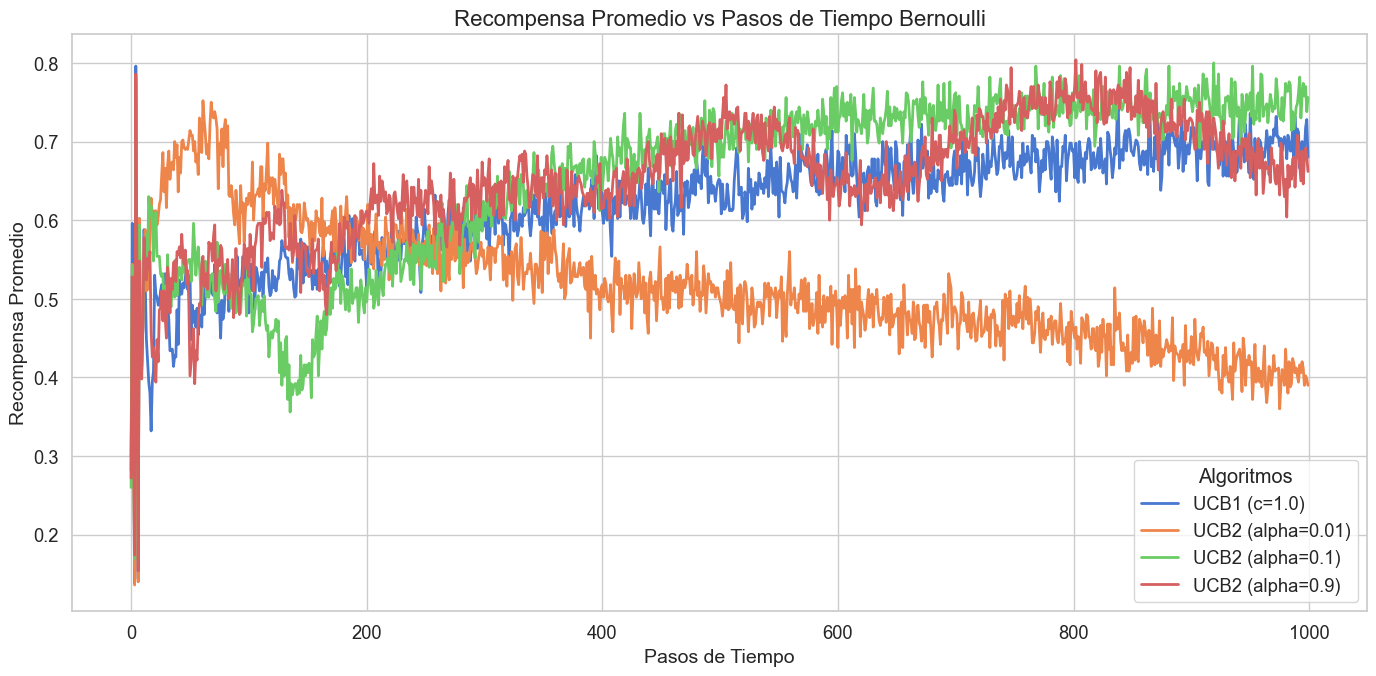

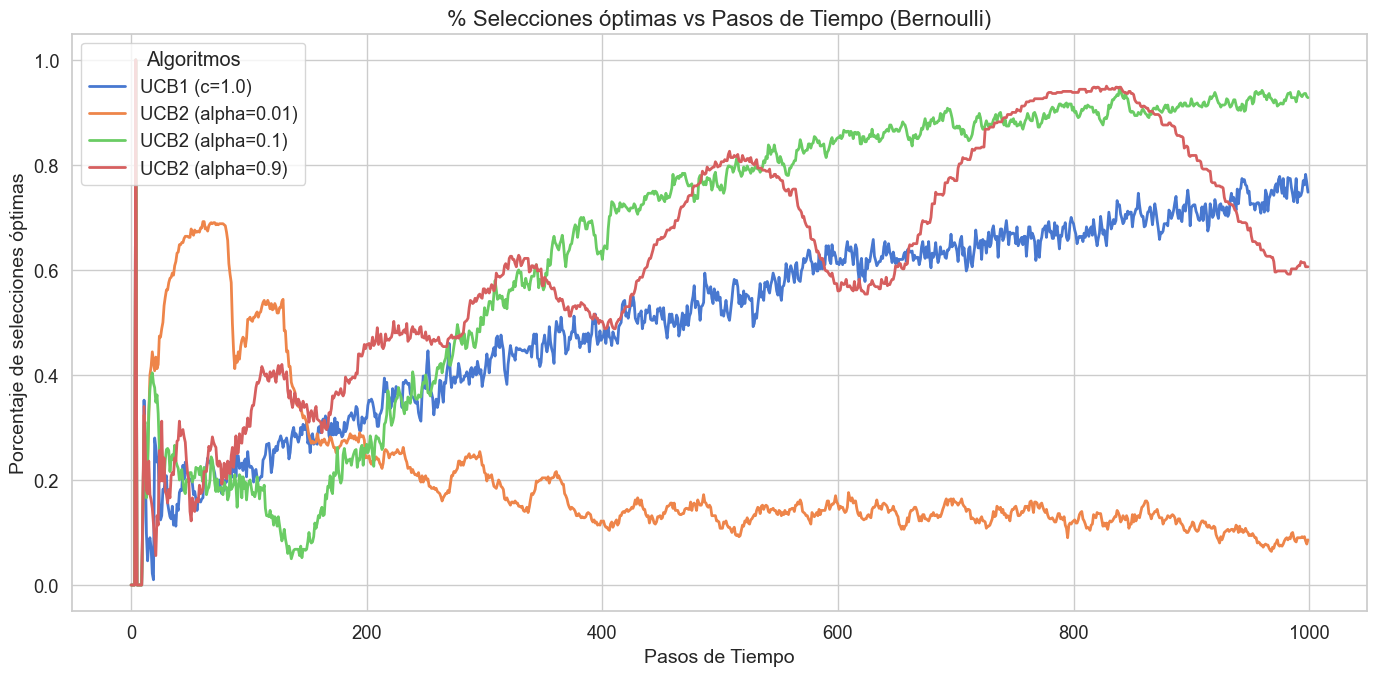

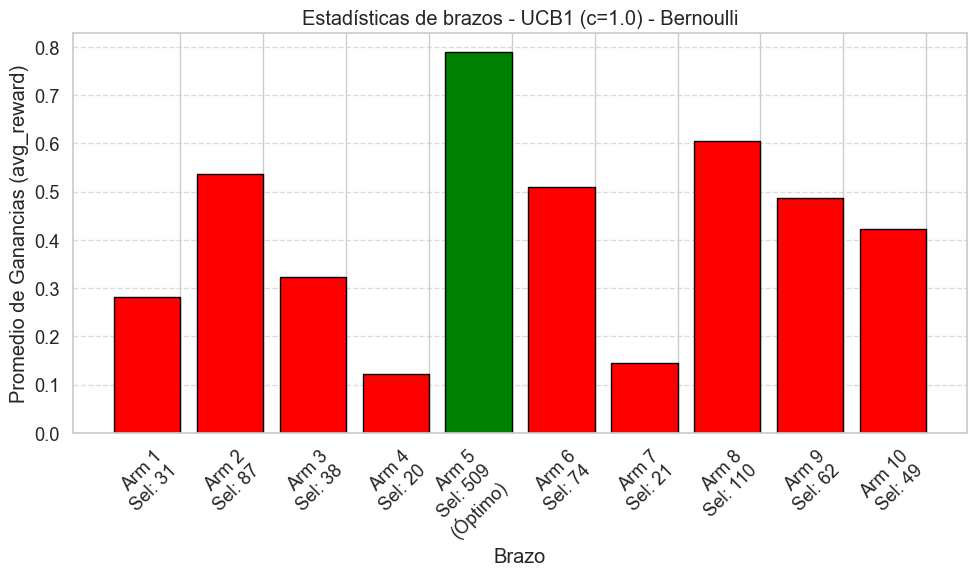

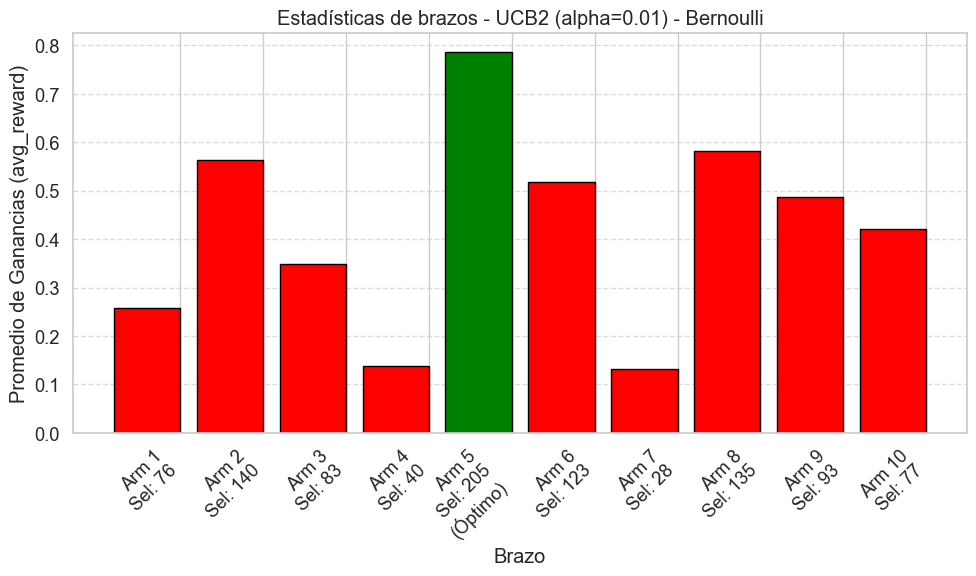

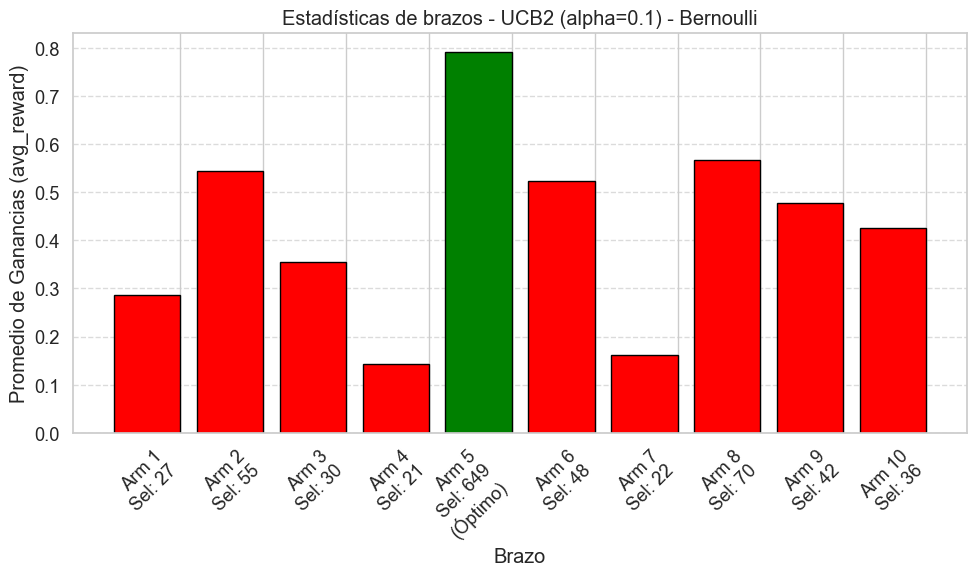

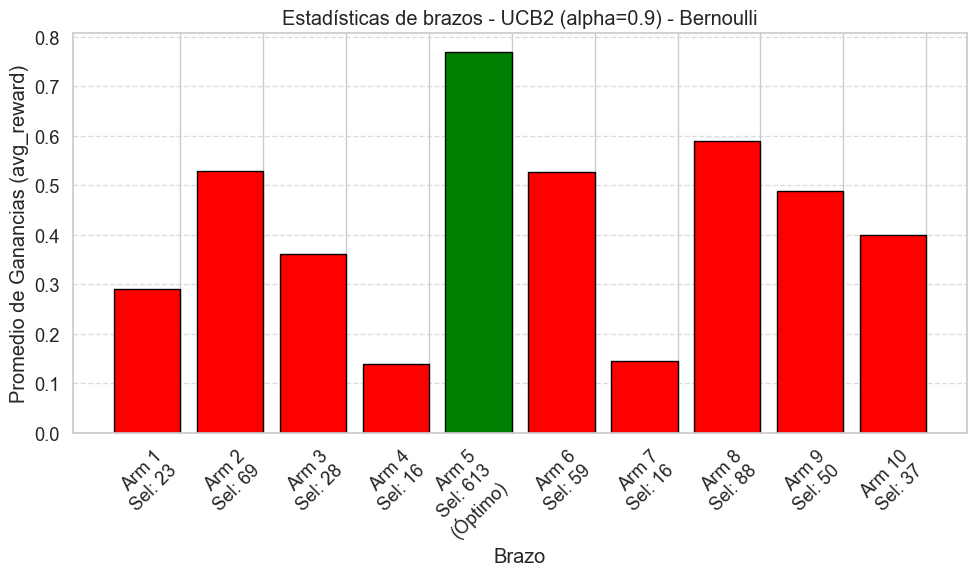

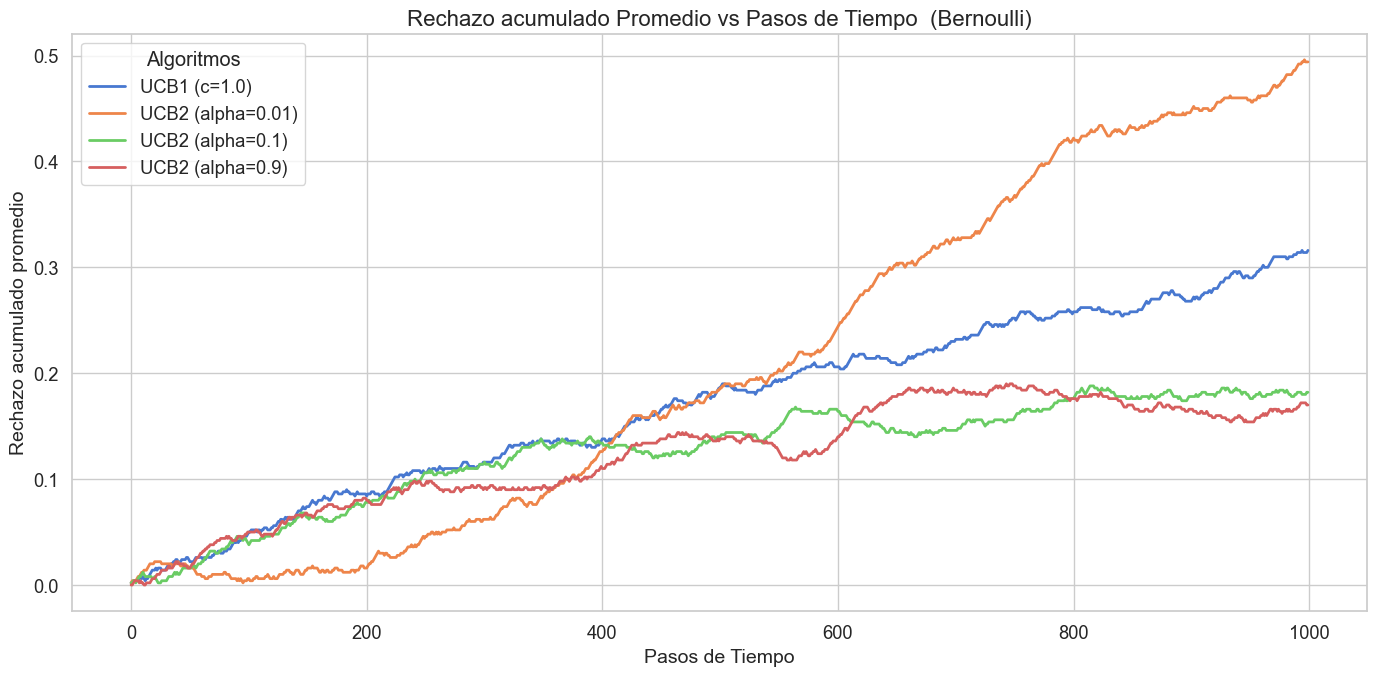

In [6]:
# Graficar los resultados
plot_average_rewards(steps, rewards, algorithms, dist="Bernoulli")
plot_optimal_selections(steps, optimal_selections, algorithms, dist="Bernoulli")
plot_arm_statistics(arm_stats_list, algorithms, dist="Bernoulli")
plot_regret(steps, regret_accumulated, algorithms, dist="Bernoulli")


### Análisis de los resultados

Observando las gráficas, podemos apreciar como las gráficas presentan un ruido mucho más significativo, al presentar la distribución de Bernoulli recompensas binarias 0 o 1. En este caso, los mejores resultados los obtiene UCB-2 con $\alpha=0.1$, superando esta vez UCB-2 ($\alpha$=0.9) a UCB-1, aunque esta segunda opción de UCB-2 presenta fuertes oscilaciones en la gráfica de porcentaje de selecciones óptimas. De nuevo, un carácter exploratorio muy bajo $\alpha=0.01$ para UCB-2 es la opción que arroja los peores resultados, debido a que tiende a una carácter explotatorio puro.

### Experimento para bandido con distribución binomial.



In [7]:
# Parámetros del experimento


k = 10  # Número de brazos
steps = 1000  # Número de pasos que se ejecutarán cada algoritmo
runs = 500  # Número de ejecuciones

# Creación del bandit
bandit = Bandit(arms=ArmBinomial.generate_arms(k, n=5)) # Generar un bandido con k brazos de distribución normal

optimal_arm = bandit.optimal_arm
print(f"Optimal arm: {optimal_arm + 1} with expected reward={bandit.get_expected_value(optimal_arm)}")

# Definir los algoritmos a comparar. En este caso son 3 algoritmos epsilon-greedy con diferentes valores de epsilon.
algorithms = [UCB1(k), UCB2(k, alpha=0.01), UCB2(k, alpha=0.1), UCB2(k, alpha=0.9)]  # Lista de algoritmos a comparar

# Ejecutar el experimento y obtener las recompensas promedio y promedio de las selecciones óptimas
rewards, optimal_selections, arm_stats_list, regret_accumulated = run_experiment(bandit, algorithms, steps, runs)

Optimal arm: 5 with expected reward=4.45


### Visualización de los resultados.


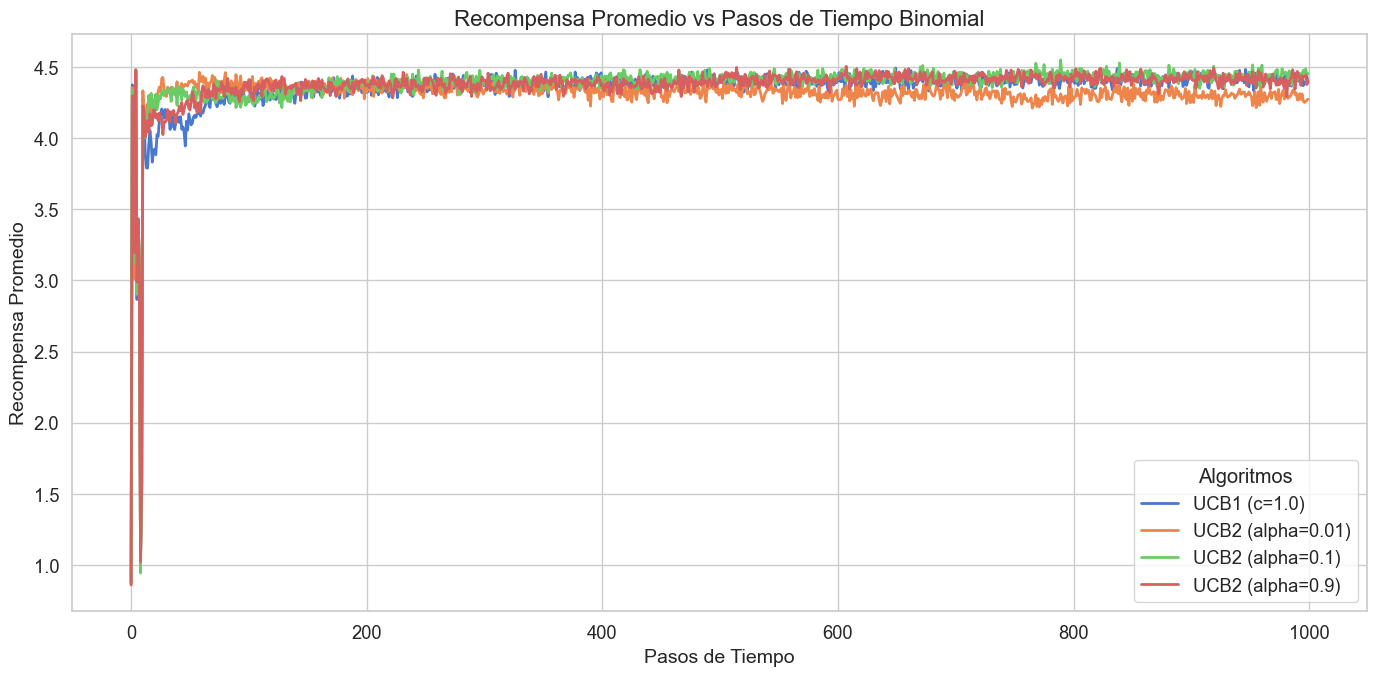

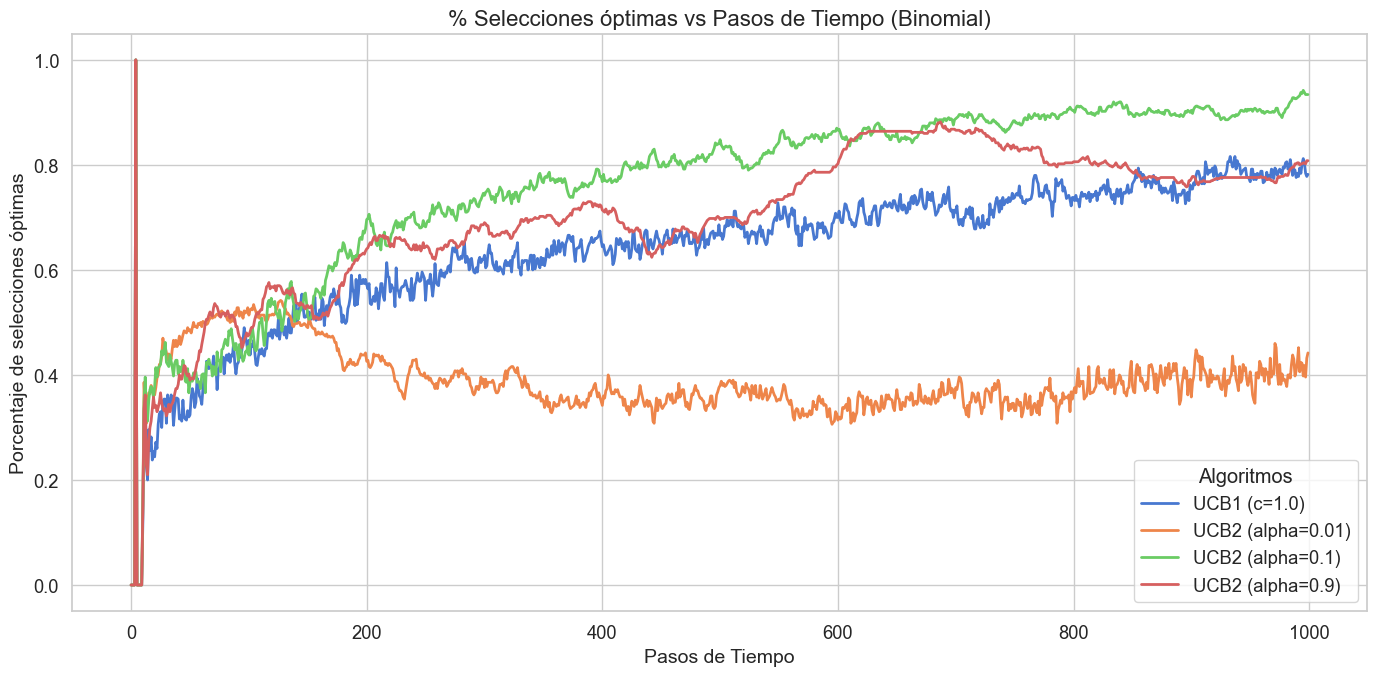

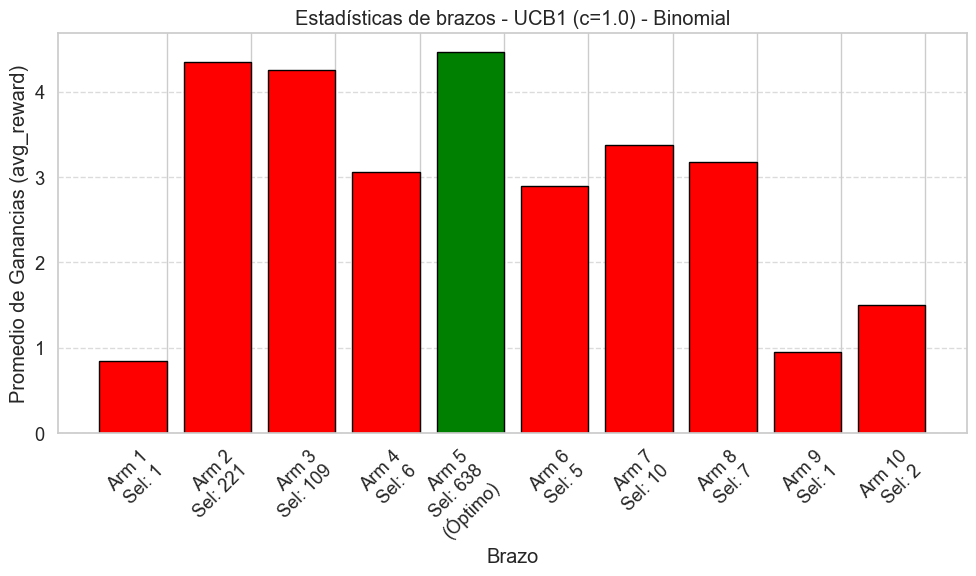

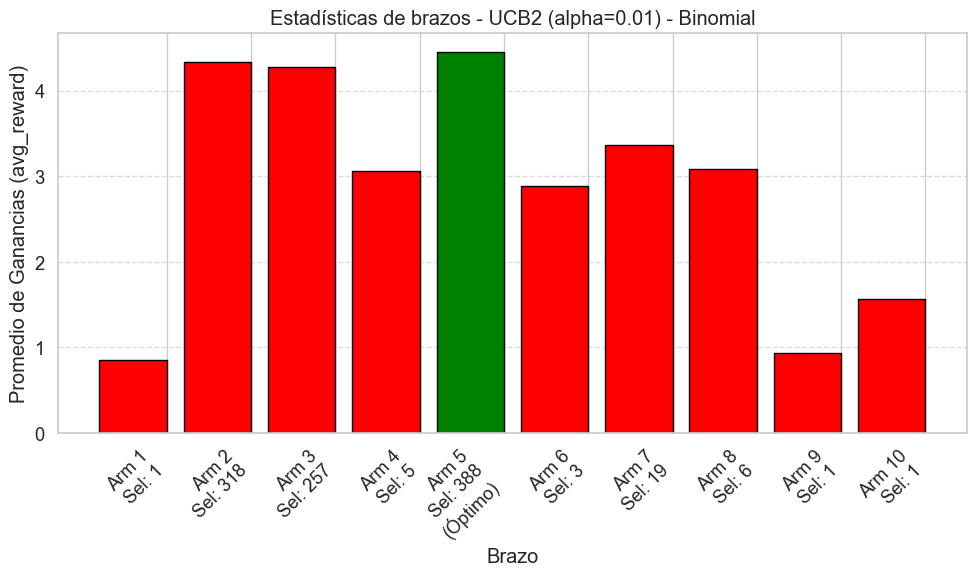

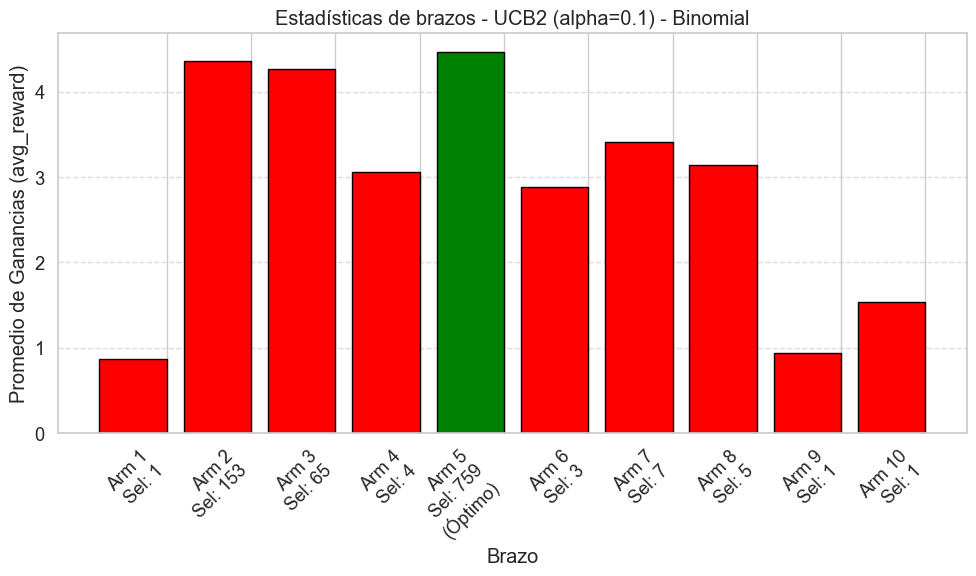

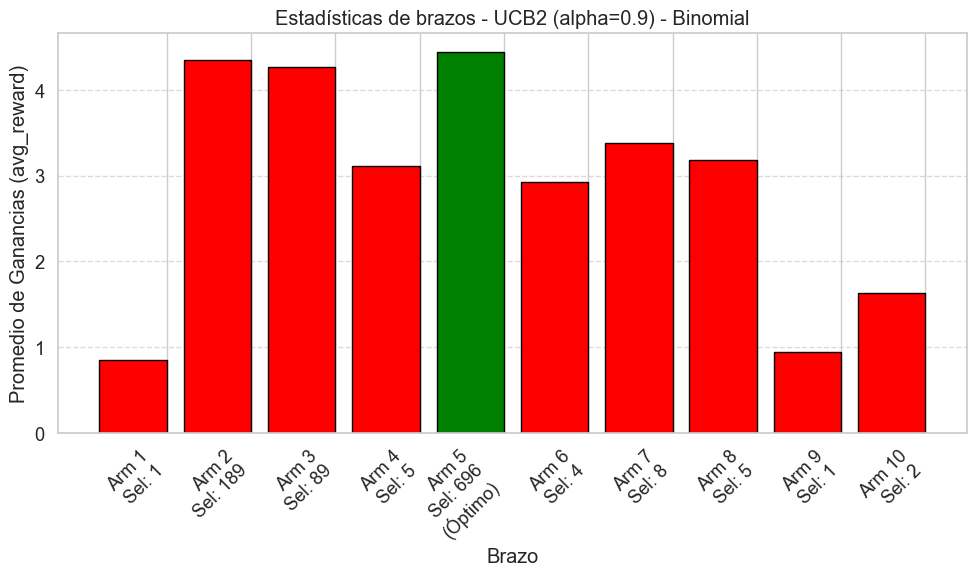

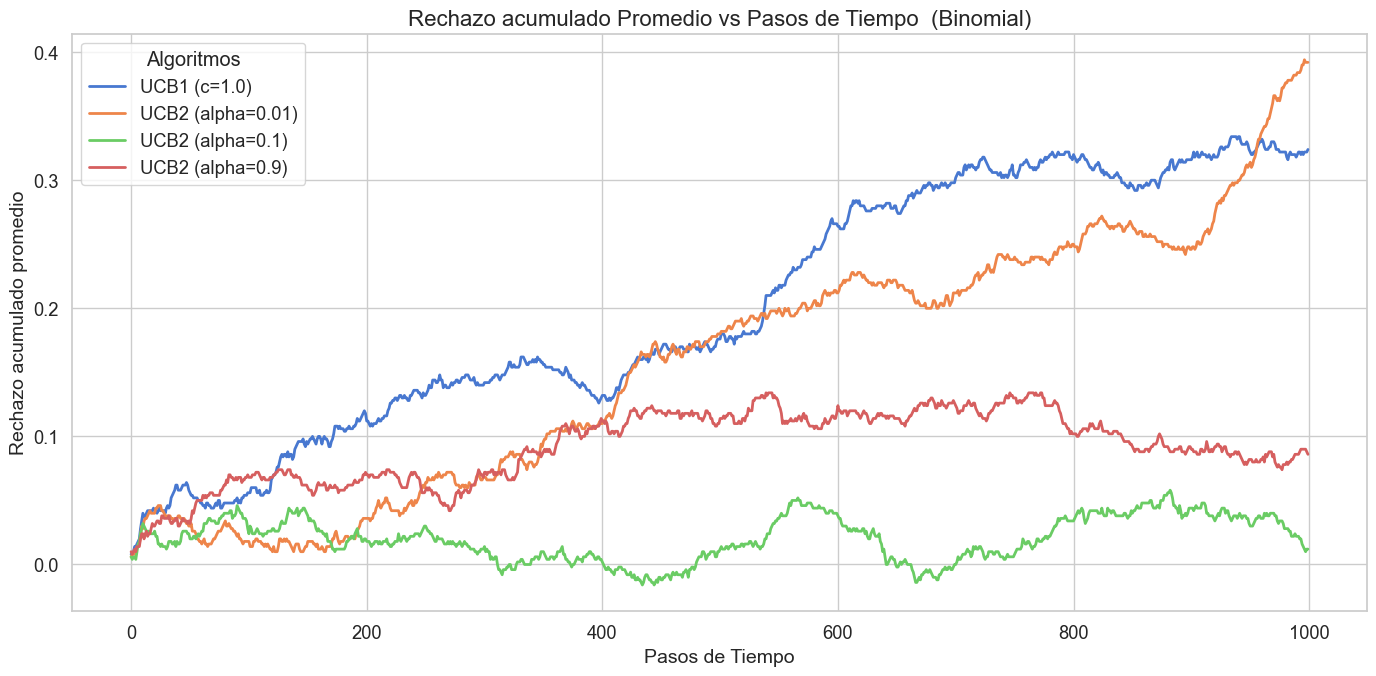

In [8]:
# Graficar los resultados
plot_average_rewards(steps, rewards, algorithms, dist="Binomial")
plot_optimal_selections(steps, optimal_selections, algorithms, dist="Binomial")
plot_arm_statistics(arm_stats_list, algorithms, dist="Binomial")
plot_regret(steps, regret_accumulated, algorithms, dist="Binomial")


### Análisis de los resultados.

Observando las gráficas de la Figura 6, vemos ya una diferencia clara entre el rendimiento de UCB-1 y UCB-2, obteniendo unos resultados bastante peores en el caso de UCB-1 que en las mejores combinaciones de UCB-2, especialmente en las gráficas de rechazo acumulado, donde se equipara a la configuración cuasi-exploratoria de UCB-2 ($\alpha=0.01$). La configuración moderadamente exploratoria de UCB-2 ($\alpha=0.1$) sigue obteniendo los mejores resultados en ambas gráficas.


## Conclusiones

En cuanto a los resultados globales de la familia UCB, UCB-2 con $\alpha=0.1$ es el algoritmo más consistente en todas las distribuciones y será el que cojamos como ganador representante delos UCB para hacer la comparación final. En cuanto al UCB-1, obtiene buenos resultados en las distribuciones de Bernoulli y normal, pero empeora notablemente en la binomial. La configuración altamente exploratoria de UCB-2 $\alpha=0.9$ por lo general obtiene resultados decentes aunque por debajo de una versión con exploración más moderada. La configuración casi plenamente explotatoria de UCB-2 ($\alpha=0.01$) es la que peores resultados obtiene para todas las distribuciones, debido a que explora muy pocas veces y no llega a conocer bien las distribuciones de recompensa de los diversos brazos.